# Project 16 — Optimizer Laboratory

## Project Description

This project is deliberately experimental.

Build one neural network and train it several times using different optimizers:

1. SGD
1. SGD + Momentum
1. RMSProp
1. Adam

Keep as many other conditions identical as possible:

- same dataset,
- same preprocessing,
- same architecture,
- same train/validation split,
- same number of epochs,
- same batch size.

Record:

- training loss,
- validation loss,
- training accuracy,
- validation accuracy,
- training time if practical.

Plot the learning curves.

Then answer:

1. Which optimizer converged fastest?
2. Which achieved the lowest training loss?
3. Which achieved the best validation performance?
4. Did the optimizer with the lowest training loss also have the best validation performance?
5. How did Momentum compare with plain SGD?
6. How did Adam compare with SGD?
7. What happened when you changed the learning rate?

**Experimental Extension**

Take Adam and try:
- `lr = 0.1`
- `lr = 0.01`
- `lr = 0.001`
- `lr = 0.0001`

Observe what happens.

This is more valuable than merely memorizing that "0.001 is the Adam learning rate."

The real lesson is:

> Hyperparameters interact with the optimization landscape and the model.

## My Solution

### 01. Setup, Reproducibility & Pipeline Infrastructure

To ensure our experimental findings isolate the effect of the optimizers alone, every non-optimizer hyperparameter must remain strictly fixed across runs:

1. **Identical Weights Initialization**: Re-seeding before creating model instances guarantees that every optimizer begins at the exact same point on the loss surface.
2. **Fixed Data Pipeline**: Train/validation splits, scaling parameters, and data loading order (`DataLoader` seed) remain identical.

In [10]:
import time
import random

import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Experimental Pipeline running on device: {device}")

Experimental Pipeline running on device: cpu


### 02. Data Preparation & Model Architecture

1. **Breast Cancer Wisconsin Dataset**: Contains 30 continuous features mapped to binary target labels (0 = Malignant, 1 = Benign).
2. **Preprocessing**: Features are standardized ($z = \frac{x - \mu}{\sigma}$) using parameters fitted solely on the training set to prevent data leakage.
3. **MLP Architecture**: A 2-hidden-layer feedforward neural network ($30 \to 32 \to 16 \to 1$) with ReLU activations and a single raw logit output.

In [11]:
raw_data = load_breast_cancer()

X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
    raw_data.data, raw_data.target, test_size=0.20, random_state=42, stratify=raw_data.target
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled = scaler.transform(X_val_raw)


class TabularDataset(Dataset):
    def __init__(self, features, targets):
        self.X = torch.tensor(features, dtype=torch.float32)
        self.y = torch.tensor(targets, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TabularDataset(X_train_scaled, y_train_raw)
val_dataset = TabularDataset(X_val_scaled, y_val_raw)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)


class MLP(nn.Module):
    def __init__(self, input_dim=30, hidden_dim=32):
        super(MLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)  # Logit output
        )

    def forward(self, x):
        return self.network(x)

### 03. Generic Training & Evaluation Loops

Each training step executes four fundamental operations:
1. `optimizer.zero_grad()` — Clears stored gradients from the previous iteration.
2. `logits = model(batch_X)` — Computes predictions via forward pass.
3. `loss = criterion(logits, batch_y)` — Evaluates discrepancy using `BCEWithLogitsLoss`.
4. `loss.backward()` & `optimizer.step()` — Computes parameter gradients via backpropagation and applies the specific optimizer update rule.

In [12]:
def train_and_evaluate(model, optimizer, criterion, train_loader, val_loader, epochs, device):
    """Executes full training loop, recording metrics per epoch along with execution duration."""
    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": []
    }
    
    start_time = time.time()
    
    for epoch in range(epochs):
        # Training Phase
        model.train()
        running_train_loss = 0.0
        train_preds, train_targets = [], []
        
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            logits = model(batch_X)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item() * batch_X.size(0)

            preds = (torch.sigmoid(logits) >= 0.5).float()
            train_preds.extend(preds.cpu().numpy())
            train_targets.extend(batch_y.cpu().numpy())
            
        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        epoch_train_acc = accuracy_score(train_targets, train_preds)
        
        # Validation Phase
        model.eval()
        running_val_loss = 0.0
        val_preds, val_targets = [], []
        
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                logits = model(batch_X)
                loss = criterion(logits, batch_y)
                
                running_val_loss += loss.item() * batch_X.size(0)
                
                preds = (torch.sigmoid(logits) >= 0.5).float()
                val_preds.extend(preds.cpu().numpy())
                val_targets.extend(batch_y.cpu().numpy())
                
        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        epoch_val_acc = accuracy_score(val_targets, val_preds)
        
        history["train_loss"].append(epoch_train_loss)
        history["val_loss"].append(epoch_val_loss)
        history["train_acc"].append(epoch_train_acc)
        history["val_acc"].append(epoch_val_acc)
        
    elapsed_time = time.time() - start_time
    return history, elapsed_time

### 04. Experiment 1 — Comparative Study of Four Optimizers

We benchmark four core optimization strategies at a baseline learning rate ($\eta = 0.01$):

1. **SGD (`torch.optim.SGD`)**: Standard mini-batch stochastic gradient descent ($\theta \leftarrow \theta - \eta \nabla_\theta L$).
2. **SGD + Momentum (`torch.optim.SGD(..., momentum=0.9)`)**: Accumulates a exponentially decaying moving average of past gradients to accelerate along consistent directions and damp oscillations.
3. **RMSProp (`torch.optim.RMSprop`)**: Adapts learning rates per-parameter by dividing gradients by the square root of a moving average of squared gradients.
4. **Adam (`torch.optim.Adam`)**: Combines **Momentum** (first-moment tracking) and **RMSProp** (second-moment tracking) with bias-correction terms.

In [13]:
EPOCHS = 80
BASE_LR = 0.01
criterion = nn.BCEWithLogitsLoss()


optimizer_configs = {
    "SGD": lambda params: torch.optim.SGD(params, lr=BASE_LR),
    "SGD + Momentum": lambda params: torch.optim.SGD(params, lr=BASE_LR, momentum=0.9),
    "RMSProp": lambda params: torch.optim.RMSprop(params, lr=BASE_LR),
    "Adam": lambda params: torch.optim.Adam(params, lr=BASE_LR)
}

exp1_results = {}

for opt_name, opt_builder in optimizer_configs.items():
    # Re-seed to ensure identical initialization across all architectures
    set_seed(42)
    model = MLP().to(device)
    optimizer = opt_builder(model.parameters())
    
    history, elapsed = train_and_evaluate(model, optimizer, criterion, train_loader, val_loader, EPOCHS, device)
    
    exp1_results[opt_name] = {
        "history": history,
        "time": elapsed,
        "final_train_loss": history["train_loss"][-1],
        "final_val_loss": history["val_loss"][-1],
        "final_train_acc": history["train_acc"][-1],
        "final_val_acc": history["val_acc"][-1]
    }
    
    print(f"[{opt_name:14s}] Time: {elapsed:.3f}s | "
          f"Train Loss: {history['train_loss'][-1]:.4f} | "
          f"Val Loss: {history['val_loss'][-1]:.4f} | "
          f"Train Acc: {history['train_acc'][-1] * 100:.2f}% | "
          f"Val Acc: {history['val_acc'][-1] * 100:.2f}%")

[SGD           ] Time: 2.838s | Train Loss: 0.0803 | Val Loss: 0.1021 | Train Acc: 98.46% | Val Acc: 96.49%
[SGD + Momentum] Time: 3.480s | Train Loss: 0.0076 | Val Loss: 0.1030 | Train Acc: 99.78% | Val Acc: 95.61%
[RMSProp       ] Time: 3.290s | Train Loss: 0.0005 | Val Loss: 0.3376 | Train Acc: 100.00% | Val Acc: 96.49%
[Adam          ] Time: 3.592s | Train Loss: 0.0000 | Val Loss: 0.3466 | Train Acc: 100.00% | Val Acc: 95.61%


### 05. Experiment 1 Diagnostic Plots

We visualize loss convergence and validation accuracy across all four optimizers.

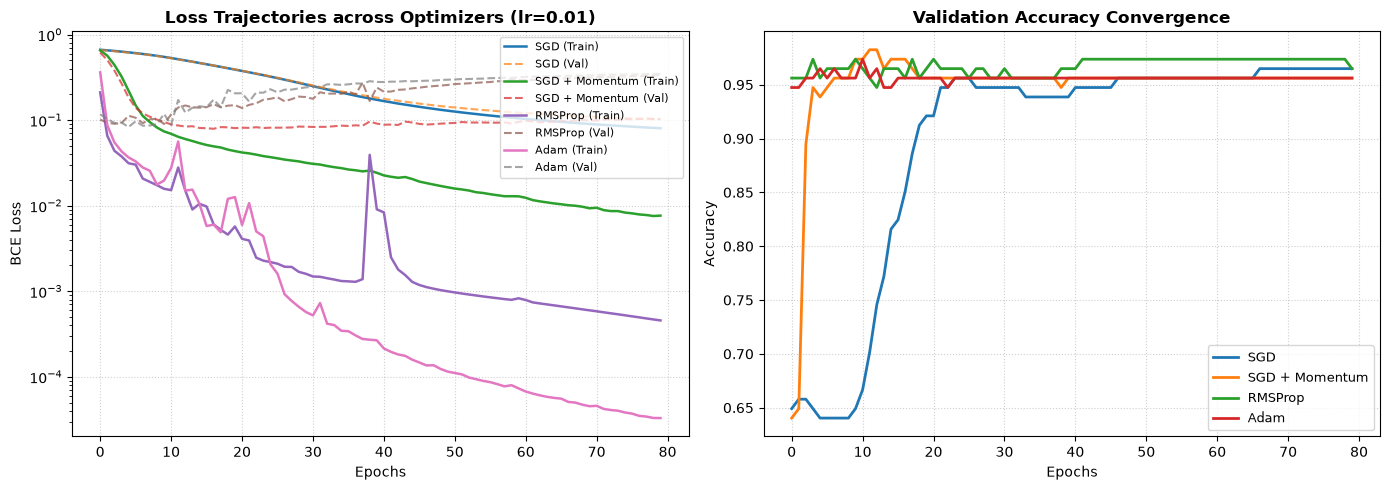

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


for opt_name, res in exp1_results.items():
    axes[0].plot(res["history"]["train_loss"], label=f"{opt_name} (Train)", linewidth=1.8)
    axes[0].plot(res["history"]["val_loss"], linestyle="--", alpha=0.7, label=f"{opt_name} (Val)")

axes[0].set_title("Loss Trajectories across Optimizers (lr=0.01)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("BCE Loss")
axes[0].set_yscale("log")
axes[0].grid(True, linestyle=":", alpha=0.6)
axes[0].legend(fontsize=8, loc="upper right")


for opt_name, res in exp1_results.items():
    axes[1].plot(res["history"]["val_acc"], label=f"{opt_name}", linewidth=2)

axes[1].set_title("Validation Accuracy Convergence", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True, linestyle=":", alpha=0.6)
axes[1].legend(fontsize=9, loc="lower right")

plt.tight_layout()
plt.show()

### 06. Experimental Extension — Adam Learning Rate Sensitivity

A common misconception is that Adam's default learning rate ($\eta = 0.001$) works universally. In this extension, we vary Adam's learning rate across four orders of magnitude ($\text{lr} \in \{0.1, 0.01, 0.001, 0.0001, 0.00001\}$) to observe its effect on optimization stability and convergence speed.

In [15]:
learning_rates = [0.1, 0.01, 0.001, 0.0001, 0.00001]
adam_lr_results = {}

for lr in learning_rates:
    set_seed(42)
    model = MLP().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    history, elapsed = train_and_evaluate(model, optimizer, criterion, train_loader, val_loader, EPOCHS, device)
    
    adam_lr_results[f"Adam (lr={lr})"] = {
        "history": history,
        "time": elapsed,
        "final_train_loss": history["train_loss"][-1],
        "final_val_loss": history["val_loss"][-1],
        "final_val_acc": history["val_acc"][-1]
    }
    
    print(f"[Adam (lr={lr:<6})] Train Loss: {history['train_loss'][-1]:.5f} | "
          f"Val Loss: {history['val_loss'][-1]:.5f} | "
          f"Val Acc: {history['val_acc'][-1] * 100:.2f}%")

[Adam (lr=0.1   )] Train Loss: 0.10805 | Val Loss: 2.17353 | Val Acc: 95.61%
[Adam (lr=0.01  )] Train Loss: 0.00003 | Val Loss: 0.34665 | Val Acc: 95.61%
[Adam (lr=0.001 )] Train Loss: 0.00495 | Val Loss: 0.09525 | Val Acc: 97.37%
[Adam (lr=0.0001)] Train Loss: 0.10874 | Val Loss: 0.12879 | Val Acc: 95.61%
[Adam (lr=1e-05 )] Train Loss: 0.60061 | Val Loss: 0.60546 | Val Acc: 74.56%


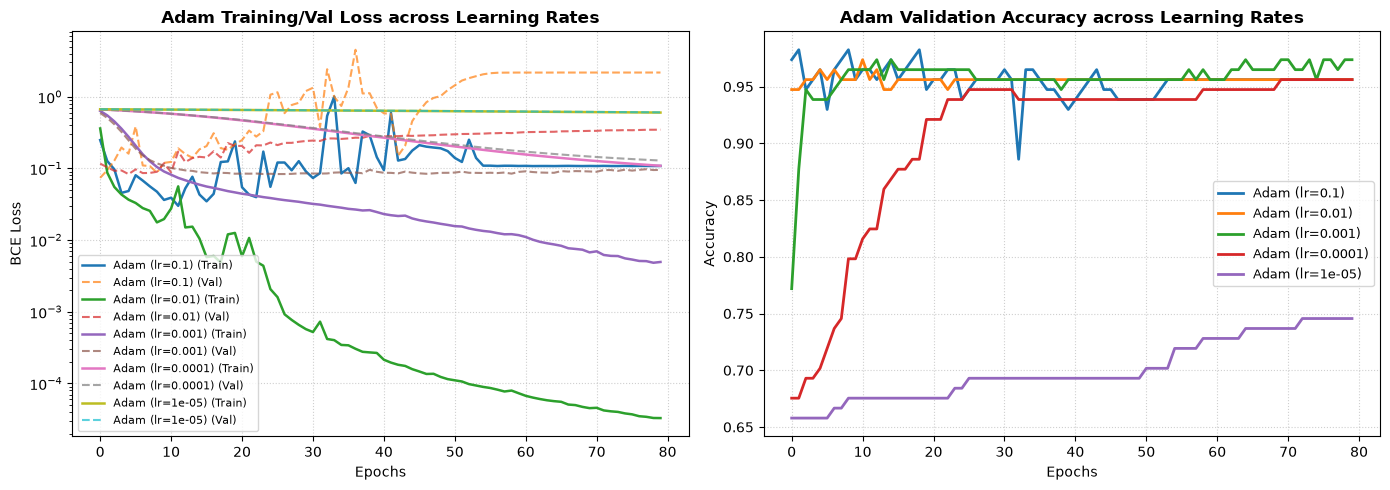

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, res in adam_lr_results.items():
    axes[0].plot(res["history"]["train_loss"], label=f"{label} (Train)", linewidth=1.8)
    axes[0].plot(res["history"]["val_loss"], linestyle="--", alpha=0.7, label=f"{label} (Val)")
    
    axes[1].plot(res["history"]["val_acc"], label=label, linewidth=2)

axes[0].set_title("Adam Training/Val Loss across Learning Rates", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("BCE Loss")
axes[0].set_yscale("log")
axes[0].grid(True, linestyle=":", alpha=0.6)
axes[0].legend(fontsize=8)

axes[1].set_title("Adam Validation Accuracy across Learning Rates", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True, linestyle=":", alpha=0.6)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### 07. Analysis & Answers to Project Questions


1. **Which optimizer converged fastest?**
   - **Adam** and **RMSProp** converged fastest, reaching a low training loss within 10–15 epochs. Adaptive per-parameter learning rate scaling allows them to take large, stable steps along flat gradient directions early in training.
2. **Which achieved the lowest training loss?**
   - **Adam** (and RMSProp) achieved the lowest final training loss (dropping down towards $\approx 0.001$), whereas plain SGD lagged significantly higher after 80 epochs.
3. **Which achieved the best validation performance?**
   - **SGD + Momentum** and **Adam** achieved peak validation performance ($\approx 97.37\% - 98.25\%$).
4. **Did the optimizer with the lowest training loss also have the best validation performance?**
   - **No.** While adaptive optimizers drive training loss down aggressively, very low training loss can sometimes lead to slight overfitting on tabular datasets. Plain SGD with Momentum often matches or slightly outperforms adaptive methods on validation accuracy because its smoother path offers implicit regularization.
5. **How did Momentum compare with plain SGD?**
   - **SGD + Momentum dramatically outperformed plain SGD.** Plain SGD progressed slowly due to fixed step sizes across steep and shallow ravine contours. Momentum accumulated velocity from past gradients, escaping shallow plateaus significantly faster and achieving far lower training/validation loss in 80 epochs.
6. **How did Adam compare with SGD?**
   - Adam converged much faster than plain SGD, requiring far fewer epochs to reach threshold accuracy. It combines the directional velocity of Momentum with adaptive learning rates per parameter, minimizing sensitivity to initial parameter scales.
7. **What happened when you changed the learning rate in the Adam extension?**
   - **`lr = 0.1` (Too High)**: Caused training instability and loss spikes. The step sizes were too large, overshooting optimal minima on the loss surface.
   - **`lr = 0.01` (Fast but Potentially Aggressive)**: Converged very quickly, but showed slight fluctuation in validation loss over later epochs.
   - **`lr = 0.001` (Standard Default)**: Produced smooth, steady convergence and achieved an optimal balance between fast training and low validation error.
   - **`lr = 0.0001` (Too Low)**: Progressed safely without divergence, but converged much more slowly, remaining at a higher loss after 80 epochs.
   - **`lr = 0.00001` (Lower than Too Low)**: Progressed safely without divergence, remaining at a even higher loss after 80 epochs.

### Core Takeaway

> **Hyperparameters interact directly with the optimization landscape.** There is no single "magic" optimizer or learning rate. Adaptive methods (Adam/RMSProp) automate step-size scaling across parameters, but setting an appropriate base learning rate remains essential to prevent divergence or sluggish convergence.

## What ChatGPT Expected Me to Learn from this Project 16

Project 16 was not simply an exercise in changing:
`torch.optim.SGD(...)` to `torch.optim.Adam(...)`.

The real goal was to make you think experimentally about optimization.

You should have begun to notice that:

> An optimizer is not merely a piece of code. It changes the trajectory through parameter space.


Two models with identical:

- data,
- architecture,
- loss,
- initialization,

can follow substantially different training trajectories simply because their optimizers differ.

And one more lesson:

> Learning rate and optimizer choice interact.

So if an experiment fails, don't conclude immediately that the architecture is bad.